In [1]:
import glob
import re
import os

import numpy as np
from pathlib import Path

from pymor.basic import *
from pymor.core.pickle import load

from RBInvParam.problems.elasticity.build import build_InstationaryModelIP

set_log_levels({
    'pymor' : 'WARN'
})

set_defaults({})


In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt

plt.style.use('default')
plt.rcParams.update({
    "text.usetex": True,          # set to True if you have LaTeX installed
    "font.family": "cm",
    #"font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 14,
    "axes.titlesize": 13,
    "legend.fontsize": 11,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "figure.dpi": 150,
})

COLOR_CYCLE = [
    "#4C72B0",  # muted blue
    "#DD8452",  # muted orange
    "#55A868",  # muted green
    "#C44E52",  # muted red
    "#8172B3",  # muted purple
    "#937860",  # muted brown
]

MARKERS = [
    "o",   # circle
    "s",   # square
    "^",   # triangle up
    "v",   # triangle down
    "D",   # diamond
    "P",   # plus-filled
]

# COLOR_CYCLE = [
#     "#000000",  # black
#     "#E69F00",  # orange
#     "#56B4E9",  # sky blue
#     "#009E73",  # bluish green
#     "#F0E442",  # yellow
#     "#0072B2",  # blue
#     "#D55E00",  # vermillion
#     "#CC79A7",  # reddish purple
# ]

# MARKERS = [
#     "o", 
#     "s", 
#     "^", 
#     "v", 
#     "D", 
#     "P", 
#     "X", 
#     "*"
# ]

In [3]:
from typing import Dict, Tuple, Optional

def get_last_file(path: Path) -> Path | None:
    # --- Step 1: Look for final files first ---
    final_candidates = [
        path / "TR_IRGNM_final.pkl",
        path / "FOM_IRGNM_final.pkl"
    ]
    
    for final_file in final_candidates:
        if final_file.exists():
            return final_file.name  # Return immediately if found
    
    # --- Step 2: If no final file exists, find the highest index file ---
    files = glob.glob(os.path.join(path, "TR_IRGNM_*.pkl"))
    files += glob.glob(os.path.join(path, "FOM_IRGNM_*.pkl"))

    indexed_files = []
    for f in files:
        match = re.search(r'(?:TR|FOM)_IRGNM_(\d+)\.pkl$', os.path.basename(f))
        if match:
            idx = int(match.group(1))
            indexed_files.append((idx, f))

    if indexed_files:
        _, max_file = max(indexed_files, key=lambda x: x[0])
        return Path(max_file).name

    print("No matching IRGNM result files found.")
    return None

def filter_and_reorder(d: Dict, pattern: str = r'.*FOM.*') -> Tuple[Dict, Optional[str]]:
    regex = re.compile(pattern)
    matching = [k for k in d if regex.search(k)]
    non_matching = [k for k in d if k not in matching]

    # Sort keys alphabetically within each group
    non_matching_sorted = sorted(non_matching)
    matching_sorted = sorted(matching)

    # Build the reordered dict: alphabetically sorted non-matching first, then matching ones
    reordered = {k: d[k] for k in non_matching_sorted}
    reordered.update({k: d[k] for k in matching_sorted})

    # Return reordered dict and the single matching key (if exactly one match)
    if len(matching_sorted) == 1:
        return reordered, matching_sorted[0]
    else:
        return reordered, None

In [23]:
#SAVE_PATH = Path('/home/dealii/workdir/figs')
#SAVE_PATH = Path('/home/benedikt/Schreibtisch/error_stagnation')

########################################################################################

#WORK_DIR = Path('/home/benedikt/Dokumente/parabolische_inverse_probleme/experiments')
#WORK_DIR = Path('/home/dealii/workdir/experiments')
#WORK_DIR = Path('/home/benedikt/Dokumente/parabolische_inverse_probleme/experiments')

# subset = 'new_baseline'
# obs_op = 'sensors'
# data_dir_path = WORK_DIR / 'new_pre_paper_version' / 'new_baseline_'

# experiment_names = []
# pattern = re.compile(rf'^.*_{obs_op}')


# #pattern = re.compile(rf'^.*')

# experiment_names += [
#     d.name for d in data_dir_path.iterdir()
#     if d.is_dir() and pattern.match(d.name)
# ]

# data_paths = [data_dir_path / experiment_name for experiment_name in experiment_names]
# file_names = [get_last_file(data_path) for data_path in data_paths]

########################################################################################

#data_dir_path = Path('/home/dealii/workdir/examples/hyperelasticity/dumps') / '20260218_094914_TR_IRGNM'
data_dir_path = Path('/home/benedikt/Dokumente/parabolische_inverse_probleme/examples/hyperelasticity/dumps') / '20260218_105552_FOM_IRGNM'

experiment_names = []
pattern = re.compile(rf'.*')

experiment_names += [
    d.name for d in data_dir_path.iterdir()
    if d.is_dir() and pattern.match(d.name)
]

data_paths = [data_dir_path]
file_names = [get_last_file(data_path) for data_path in data_paths]

########################################################################################

setup = None
data = {}
optimizer_parameters = {}

for (data_path, file_name) in zip(data_paths, file_names):            

    try:
        with open(data_path / file_name, 'rb') as file:
            data_ = load(file)
        data[str(data_path.name)] = data_
    except TypeError:
        print(f"Can not find dumps for {data_path}")
    except:
        print(f"Can not open {data_path / file_name}")

    if not setup:
        with open(data_path / 'setup.pkl', 'rb') as file:
            setup = load(file)

    
    optimizer_parameter_path = data_path / 'optimizer_parameter.pkl'
    with open(optimizer_parameter_path, 'rb') as file:
        optimizer_parameter = load(file)
        
    optimizer_parameters[str(data_path.name)] = optimizer_parameter

data, FOM_key = filter_and_reorder(data, pattern=r'.*FOM.*')
#assert FOM_key

# if not 'FOM' in locals():
#     FOM = build_InstationaryModelIP(setup=setup)

print(data.keys())


dict_keys(['20260218_105552_FOM_IRGNM'])


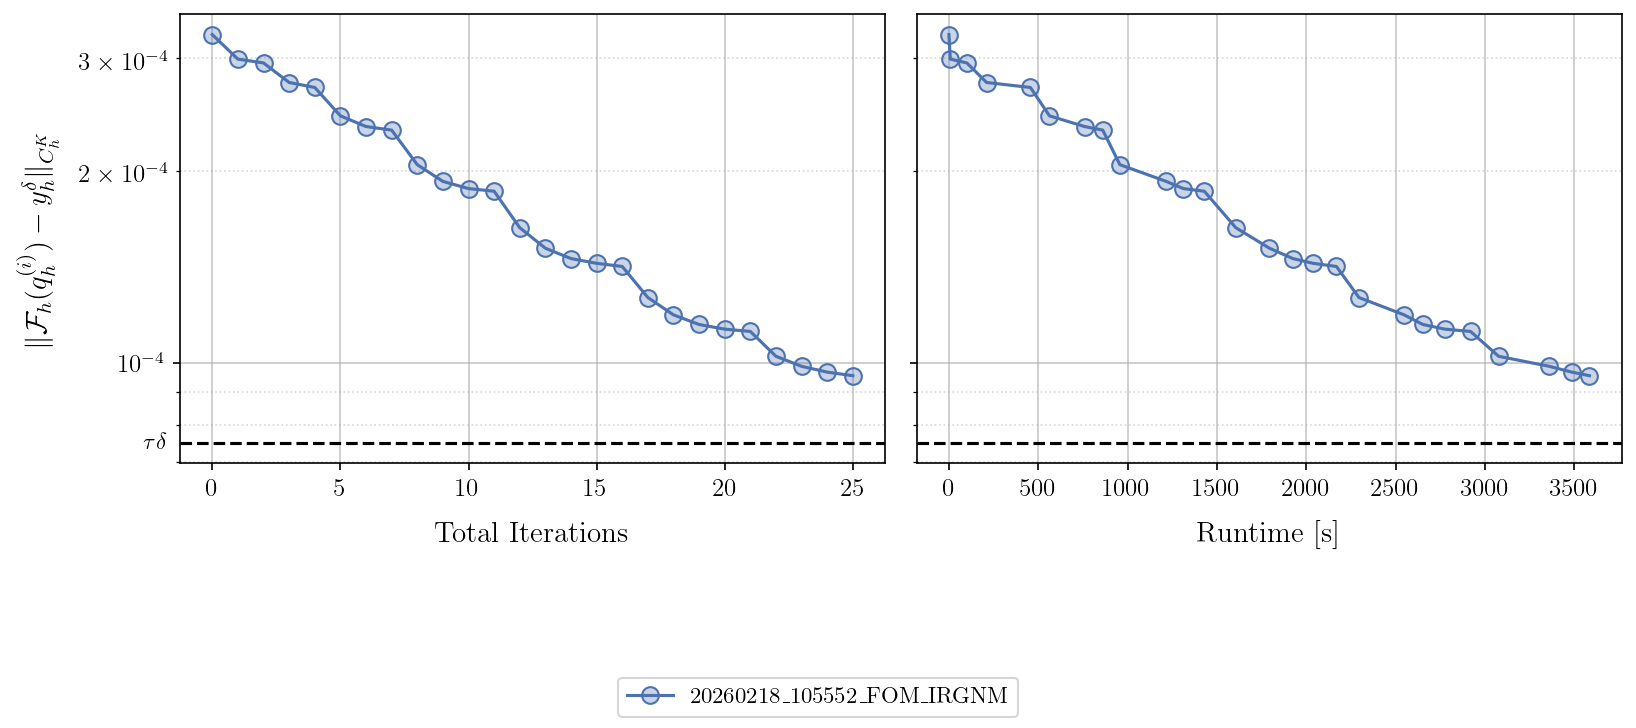

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Helper functions
# =========================
def compute_Js(experiment_data):
    """
    Return sqrt(2J) array for an experiment.
    Handles both flat 'J' and 'inner_loop_statistics' structure.
    """
    Js = []
    try:
        inner_loop_statistics = experiment_data.get('inner_loop_statistics', None)
        if inner_loop_statistics:
            for inner_loop_statistic in inner_loop_statistics:
                Js += inner_loop_statistic['J']
        else:
            Js += experiment_data['J']
    except Exception:
        Js += experiment_data['J']

    Js = np.sqrt(2 * np.array(Js))
    return Js 


def compute_threshold(optimizer_parameters, FOM_key, delta):
    """
    Compute threshold = sqrt(2 * (0.5 * tau^2 * delta^2)) = tau * delta.
    """
    try:
        tau = optimizer_parameters[FOM_key]['tau']
    except Exception:
        # Fallback: use last entry in optimizer_parameters
        tau = list(optimizer_parameters.values())[-1]['tau']
    return np.sqrt(2 * (0.5 * tau**2 * delta**2))



# =========================
# Figure + common settings
# =========================
fig, (ax_iter, ax_time) = plt.subplots(
    1, 2, figsize=(12, 5), sharey=True
)
fig.subplots_adjust(wspace=0.25)

fontsize = 11

# =========================
# Threshold
# =========================
delta = setup['noise_level']
threshold = compute_threshold(optimizer_parameters, FOM_key, delta)

# =========================
# Left: sqrt(2J) vs iterations
# =========================
for idx, (experiment_name, experiment_data) in enumerate(data.items()):
    Js = compute_Js(experiment_data)

    base_color = COLOR_CYCLE[idx % len(COLOR_CYCLE)]
    marker = MARKERS[idx % len(MARKERS)]

    facecolor = mpl.colors.to_rgba(base_color, alpha=0.3)   # semi-transparent
    edgecolor = mpl.colors.to_rgba(base_color, alpha=1.0)   # opaque
    markersize = 8

    ax_iter.plot(
        np.arange(len(Js)),
        Js,
        marker=marker,
        markersize=markersize,
        linestyle="-",
        color=edgecolor,             # line color (opaque)
        markerfacecolor=facecolor,   # semi-transparent fill
        markeredgecolor=edgecolor,   # solid border
        markeredgewidth=1.0,
        label=experiment_name,
    )

ax_iter.set_xlabel("Total Iterations", labelpad=10)
ax_iter.set_yscale("log")
ax_iter.grid(True, which="major", linestyle="-", alpha=0.7)
ax_iter.grid(True, which="minor", linestyle=":", alpha=0.5)

# =========================
# Right: sqrt(2J) vs runtime
# =========================
for idx, (experiment_name, experiment_data) in enumerate(data.items()):
    Js = np.sqrt(2 * np.array(experiment_data['J']))    
    try:
        times = np.array([0])
        times = np.append(times, experiment_data['total_runtime'])
    except Exception:
        times = np.array([0])
        times = np.append(times, experiment_data['time_steps'])

    if len(Js) != len(times):
        times = times[:-1]
        times = times[1:]
        times[0] = 0

        

    n = min(len(times), len(Js))
    base_color = COLOR_CYCLE[idx % len(COLOR_CYCLE)]
    marker = MARKERS[idx % len(MARKERS)]

    facecolor = mpl.colors.to_rgba(base_color, alpha=0.3)   # semi-transparent
    edgecolor = mpl.colors.to_rgba(base_color, alpha=1.0)   # opaque
    markersize = 8

    ax_time.plot(
        times,
        Js,
        marker=marker,
        markersize=markersize,
        linestyle="-",
        color=edgecolor,
        markerfacecolor=facecolor,
        markeredgecolor=edgecolor,
        markeredgewidth=1.0,
        label=experiment_name,
    )

ax_time.set_xlabel("Runtime [s]", labelpad=10)
ax_time.set_yscale("log")
ax_time.grid(True, which="major", linestyle="-", alpha=0.7)
ax_time.grid(True, which="minor", linestyle=":", alpha=0.5)

# =========================
# Legend merging
# =========================
handles1, labels1 = ax_iter.get_legend_handles_labels()
handles2, labels2 = ax_time.get_legend_handles_labels()

combined = {}
for h, l in zip(handles1 + handles2, labels1 + labels2):
    if l not in combined:
        combined[l] = h

ax_iter.set_ylabel(
    r"$\|\mathcal{F}_h(q_h^{(i)}) - y_h^{\delta}\|_{C^K_h}$",
    labelpad=10.0,
)

# for ax in (ax_iter, ax_time):
#     # Log scale
#     ax.set_yscale("log")

#     ax.yaxis.set_major_locator(mpl.ticker.LogLocator(base=10.0))

#     # Minor ticks at 5 * 10^n
#     ax.yaxis.set_minor_locator(
#         mpl.ticker.LogLocator(base=10.0, subs=(5.0,), numticks=100)
#     )
#     # Optional: hide minor tick labels so only majors are labeled
#     ax.yaxis.set_minor_formatter(mpl.ticker.NullFormatter())

#     # Elongate ticks
#     ax.tick_params(axis="y", which="major", length=6, width=1.2)
#     ax.tick_params(axis="y", which="minor", length=4, width=1.0)

#     # Keep your grids
#     ax.grid(True, which="major", linestyle="-", alpha=0.7)
#     ax.grid(True, which="minor", linestyle=":", alpha=0.5)

if threshold is not None:
    # Draw threshold line as before
    ax_iter.axhline(threshold, color="black", linestyle="--", linewidth=1.5)
    ax_time.axhline(threshold, color="black", linestyle="--", linewidth=1.5)

    # Add ONE label on the left subplot
    ax_iter.text(
        -0.02, threshold,                  # x slightly outside axes (left side)
        r"$\tau \delta$",
        fontsize=11,
        ha="right",
        va="center",
        transform=ax_iter.get_yaxis_transform()
    )

handles = list(combined.values())
labels = list(combined.keys())

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=min(4, len(labels)),
    frameon=True,
    fontsize=fontsize,
)

plt.tight_layout(rect=[0.06, 0.20, 0.98, 0.98])

# =========================
# TikZ export
# =========================
# import matplot2tikz

# matplot2tikz.save(
#     SAVE_PATH / "log_errors_horizon_decay_plots.tex",
#     figure=fig,
#     flavor="latex",
#     extra_axis_parameters={
#         # force nice ylabel formatting in LaTeX:
#         # place legend below the group (PGFPlots coordinates)
#         r"legend style={font=\small, at={(0.5,-0.20)}, anchor=north}",
#         # modest grid styles
#         r"grid style={gray!50}",
#         r"minor grid style={dotted,gray!30}",
#     },
# )



KeyError: 'dim_Q_r'

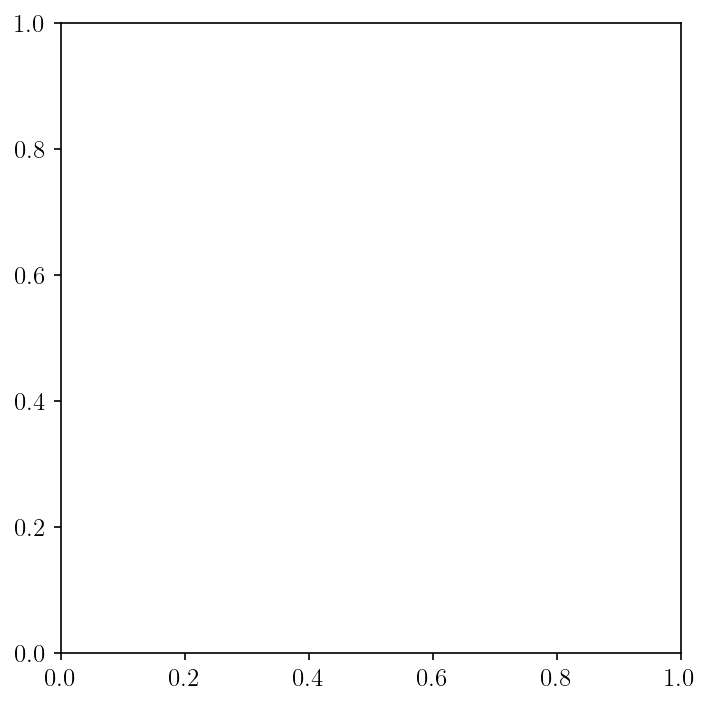

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec

# --- Figure + layout ---
fig = plt.figure(figsize=(12, 12))
gs = gridspec.GridSpec(2, 2, width_ratios=[1, 1])
gs.update(wspace=0.25)

# =========================
# Left
# =========================
ax = fig.add_subplot(gs[0])
exclude_last_idx = None
#exclude_last_idx = -1

for experiment_name, experiment_data in dict(list(data.items())[:exclude_last_idx]).items():
    dim_Q_r = experiment_data['dim_Q_r']
    ax.stairs(dim_Q_r, label=experiment_name, baseline=None, linewidth=2)

ax.set_title(r'$\dim Q_r$')
ax.set_ylabel(r'$\dim Q_r$')
ax.set_xlabel('Outer Iterations')
ax.grid(True, which='major', linestyle='-', alpha=0.7)
ax.grid(True, which='minor', linestyle=':', alpha=0.5)

# =========================
# Middel
# =========================
ax = fig.add_subplot(gs[1])

for experiment_name, experiment_data in dict(list(data.items())[:exclude_last_idx]).items():
    dim_V_r = experiment_data['dim_V_r']
    ax.stairs(dim_V_r, label=experiment_name, baseline=None, linewidth=2)

ax.set_title(r'$\dim V_r$')
ax.set_ylabel(r'$\dim V_r$')
ax.set_xlabel('Outer Iterations')
ax.grid(True, which='major', linestyle='-', alpha=0.7)
ax.grid(True, which='minor', linestyle=':', alpha=0.5)

# =========================
# Right
# =========================
ax = fig.add_subplot(gs[2])

for experiment_name, experiment_data in dict(list(data.items())[:exclude_last_idx]).items():
    ax.plot(experiment_data['rel_est_error_J_r'], marker='o', label=experiment_name)
        

ax = fig.add_subplot(gs[2])

for experiment_name, experiment_data in dict(list(data.items())[:exclude_last_idx]).items():
    ax.plot(experiment_data['rel_est_error_J_r'], marker='o', label=experiment_name)
        


ax.axhline(0.30, color='black')

ax.set_title(r'Rel. error')
ax.set_ylabel('rel_est_error_J_r')
ax.set_xlabel('Outer iterations')
ax.set_yscale('log')
ax.grid(True, which='major', linestyle='-', alpha=0.7)
ax.grid(True, which='minor', linestyle=':', alpha=0.5)
# =========================
# Shared ylabel and joint legend
# =========================


# Joint legend below both subplots (with padding to avoid overlap)
handles, labels = ax_iter.get_legend_handles_labels()
#custom_labels = ['TR-IRGNM-I','TR-IRGNM-II','TR-IRGNM-III','TR-IRGNM-IV']
#fig.legend(handles, custom_labels, loc='lower center', ncol=4, frameon=False, fontsize=fontsize, bbox_to_anchor=(0.5, 0))

fig.legend(handles, labels, loc='lower center', ncol=2, frameon=False, fontsize=fontsize, bbox_to_anchor=(0.5, -0.05))

# Adjust layout: reserve space for legend and avoid overlap
plt.tight_layout(rect=[0.05, 0.18, 1, 1])  # extra bottom margin

plt.show()
#fig.savefig(SAVE_PATH / Path(f'{subset}_{obs_op}_additional_infos.pdf'), bbox_inches="tight")



In [29]:
stats = data['new_baseline_TR_sensors_time_step']['inner_loop_statistics']

cmap = plt.cm.get_cmap('tab10')
colors = cmap.colors

# container for merged values
merged = {}

for entry in stats:  # iterate through each inner statistics entry
    for key, value in entry['errors'].items():  # each key corresponds to a list of numbers
        if key not in merged:
            merged[key] = []          # initialize list if not present
        merged[key].extend(value)     # append values to list
        
for key in merged:
    merged[key] = np.array(merged[key])       # <<< now numpy arrays


colors = {
    'rel_err_u' : colors[0], 
    'rel_err_p' : colors[1], 
    'rel_err_lin_u' : colors[0],
    'rel_err_lin_p' : colors[1], 
    'rel_err_J' : colors[2], 
    'rel_err_nabla_J' : colors[3], 
    'rel_err_lin_J' : colors[2], 
    'rel_err_nabla_lin_J' : colors[3]
}

linestyles = {
    'rel_err_u' : '-', 
    'rel_err_p' : '-', 
    'rel_err_lin_u' : '--', 
    'rel_err_lin_p' : '--', 
    'rel_err_J' : '-',
    'rel_err_nabla_J' : '-', 
    'rel_err_lin_J' : '--',
    'rel_err_nabla_lin_J' : '--',
}

for key, values in merged.items():
    if key.startswith("rel_"):
        plt.plot(values, label=key, color=colors[key], linestyle=linestyles[key])

plt.title('Relative errors')
plt.yscale("log")             # LOG SCALE
plt.xlabel("Index")
plt.ylabel("Errors")
plt.grid()  # major & minor grid

# legend below the plot
fontsize = 10  # or whatever you like

handles, labels = plt.gca().get_legend_handles_labels()   # <<< FIXED

plt.legend(
    handles,
    labels,
    loc='upper center',
    ncol=4,
    frameon=False,
    fontsize=fontsize,
    bbox_to_anchor=(0.5, -0.15)  # place below
)

#plt.tight_layout()
plt.show()
#plt.savefig(SAVE_PATH / Path(f'rel_errors.pdf'), bbox_inches="tight")


KeyError: 'new_baseline_TR_sensors_time_step'

In [79]:
#data['20251127_155405_TR_IRGNM']['inner_loop_statistics'][0]['errors']

stats = data['defect_inside_material_TR_grid_time_step']['inner_loop_statistics']


cmap = plt.cm.get_cmap('tab10')
colors = cmap.colors


# container for merged values
merged = {}

for entry in stats:  # iterate through each inner statistics entry
    for key, value in entry['errors'].items():  # each key corresponds to a list of numbers
        if key not in merged:
            merged[key] = []          # initialize list if not present
        merged[key].extend(value)     # append values to list
        
for key in merged:
    merged[key] = np.array(merged[key])       # <<< now numpy arrays

colors = {
    'err_u'            : colors[0], 
    'err_p'            : colors[1], 
    'err_lin_u'        : colors[0],
    'err_lin_p'        : colors[1], 
    'err_J'            : colors[2], 
    'err_nabla_J'      : colors[3], 
    'err_lin_J'        : colors[2], 
    'err_nabla_lin_J'  : colors[3]
}

linestyles = {
    'err_u'            : '-', 
    'err_p'            : '-', 
    'err_lin_u'        : '--', 
    'err_lin_p'        : '--', 
    'err_J'            : '-',
    'err_nabla_J'      : '-', 
    'err_lin_J'        : '--',
    'err_nabla_lin_J'  : '--',
}



for key, values in merged.items():
    if not key.startswith("rel_"):
        plt.plot(values, label=key, color=colors[key], linestyle=linestyles[key])

plt.title('Absolut errors')
plt.yscale("log")             # LOG SCALE
plt.xlabel("Index")
plt.ylabel("Errors")
plt.grid()  # major & minor grid

# legend below the plot
fontsize = 10  # or whatever you like

handles, labels = plt.gca().get_legend_handles_labels()   # <<< FIXED

plt.legend(
    handles,
    labels,
    loc='upper center',
    ncol=4,
    frameon=False,
    fontsize=fontsize,
    bbox_to_anchor=(0.5, -0.15)  # place below
)

#plt.tight_layout()
#plt.show()
#plt.savefig(SAVE_PATH / Path(f'abs_errors.pdf'), bbox_inches="tight")


/tmp/ipykernel_3506/1034711607.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10')


KeyError: 'norm_delta_q'

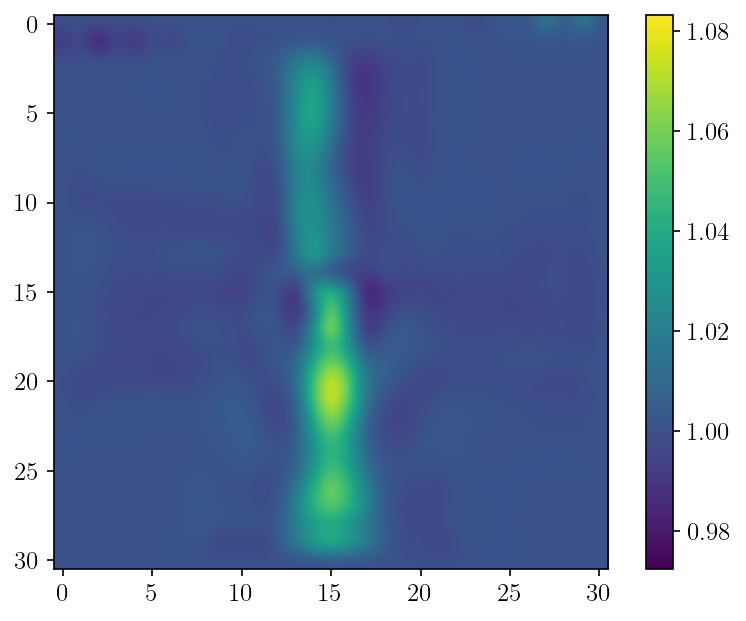

In [28]:
plt.imshow(data['20260218_105552_FOM_IRGNM']['q'][-1].to_numpy().reshape((31,31)), interpolation='bicubic')
#plt.imshow(data['TR']['q'][-1].to_numpy().reshape((9,9)))
plt.colorbar() 

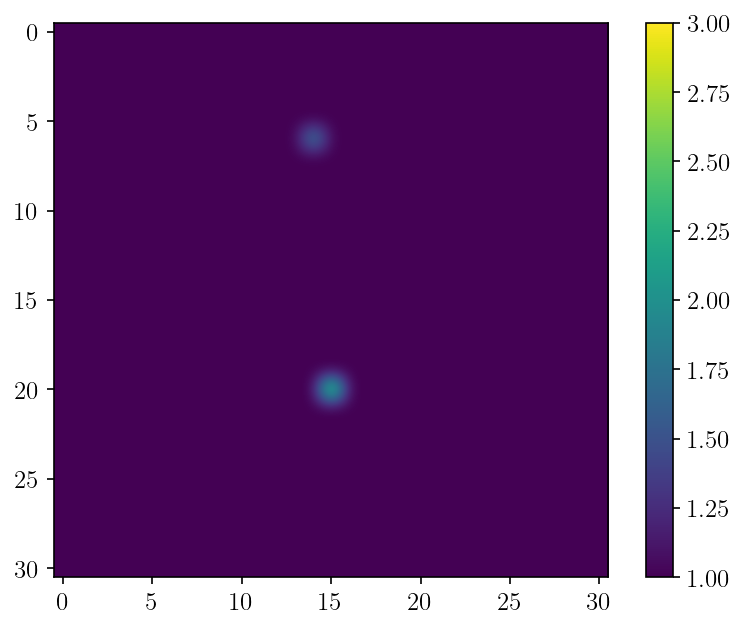

In [26]:
plt.imshow(setup['q_exact'].reshape((31,31)), interpolation='bicubic')
#plt.imshow(setup['q_exact'].reshape((9,9)))

plt.colorbar() 

In [ ]:
43 * 43